In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as pticker
import os
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
sns.set_theme(style='whitegrid',palette='muted')
df = pd.read_csv('GlobalMart_Sales_Dataset.csv')

In [2]:
print('Shape:', df.shape)          
print('Columns:', df.columns.tolist())
print(df.head())                   
print(df.dtypes)                   
print(df.describe()) 

Shape: (3795, 16)
Columns: ['Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer Name', 'Segment', 'City', 'State', 'Region', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']
         Order ID  Order Date   Ship Date       Ship Mode Customer Name  \
0  ORD-2022-00001  2021-01-08  2021-01-12  Standard Class    Richard Li   
1  ORD-2023-00002  2021-01-31  2021-02-05  Standard Class  Deepa Miller   
2  ORD-2024-00003  2021-01-10  2021-01-16    Second Class   Vikram Yang   
3  ORD-2021-00004  2021-01-15  2021-01-20  Standard Class  Vikram Kumar   
4  ORD-2022-00005  2021-01-15  2021-01-19        Same Day  Huang Harris   

     Segment         City          State   Region         Category  \
0   Consumer       Boston  Massachusetts     East        Furniture   
1   Consumer      Jackson    Mississippi    South        Furniture   
2  Corporate  Minneapolis      Minnesota  Central       Technology   
3   Consumer      Seattle     Washington     We

In [3]:
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer Name    0
Segment          0
City             0
State            0
Region           0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [4]:
print('Duplicate rows:', df.duplicated().sum())

Duplicate rows: 0


In [5]:
print('Regions:', df['Region'].unique())
print('Categories:', df['Category'].unique())
print('Segments:', df['Segment'].unique())

Regions: ['East' 'South' 'Central' 'West']
Categories: ['Furniture' 'Technology' 'Office Supplies']
Segments: ['Consumer' 'Corporate' 'Home Office']


In [6]:
print('Order Date range:', df['Order Date'].min(), 'to', df['Order Date'].max())

Order Date range: 2021-01-01 to 2024-12-31


In [7]:
df.columns = df.columns.str.strip().str.replace(' ', '_').str.lower()

In [8]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['ship_date']  = pd.to_datetime(df['ship_date'])

In [9]:
df['order_year']    = df['order_date'].dt.year
df['order_month']   = df['order_date'].dt.month
df['order_quarter'] = df['order_date'].dt.quarter
df['order_month_name'] = df['order_date'].dt.strftime('%B')

In [10]:
df = df.drop_duplicates()

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3795 entries, 0 to 3794
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          3795 non-null   object        
 1   order_date        3795 non-null   datetime64[ns]
 2   ship_date         3795 non-null   datetime64[ns]
 3   ship_mode         3795 non-null   object        
 4   customer_name     3795 non-null   object        
 5   segment           3795 non-null   object        
 6   city              3795 non-null   object        
 7   state             3795 non-null   object        
 8   region            3795 non-null   object        
 9   category          3795 non-null   object        
 10  sub-category      3795 non-null   object        
 11  product_name      3795 non-null   object        
 12  sales             3795 non-null   float64       
 13  quantity          3795 non-null   int64         
 14  discount          3795 n

In [12]:
df['sales'] = df['sales'].astype(float).round(2)
df['profit'] = df['profit'].astype(float).round(2)

In [13]:
df['profit_margin'] = (df['profit'] / df['sales'] * 100).round(2)
df['revenue_per_unit'] = (df['sales'] / df['quantity']).round(2)
df['ship_days'] = (df['ship_date'] - df['order_date']).dt.days

In [14]:
print('Cleaned shape:', df.shape)
print('Missing values:', df.isnull().sum().sum())
print(df.head(3))

Cleaned shape: (3795, 23)
Missing values: 0
         order_id order_date  ship_date       ship_mode customer_name  \
0  ORD-2022-00001 2021-01-08 2021-01-12  Standard Class    Richard Li   
1  ORD-2023-00002 2021-01-31 2021-02-05  Standard Class  Deepa Miller   
2  ORD-2024-00003 2021-01-10 2021-01-16    Second Class   Vikram Yang   

     segment         city          state   region    category  ... quantity  \
0   Consumer       Boston  Massachusetts     East   Furniture  ...        3   
1   Consumer      Jackson    Mississippi    South   Furniture  ...        3   
2  Corporate  Minneapolis      Minnesota  Central  Technology  ...        1   

  discount  profit  order_year  order_month  order_quarter  order_month_name  \
0      0.0  733.29        2021            1              1           January   
1      0.0  157.65        2021            1              1           January   
2      0.4   35.15        2021            1              1           January   

   profit_margin  revenue

In [15]:
df.to_csv('cleaned_sales.csv', index=False)
print('Cleaned data saved successfully!')

Cleaned data saved successfully!


Sales Distribution

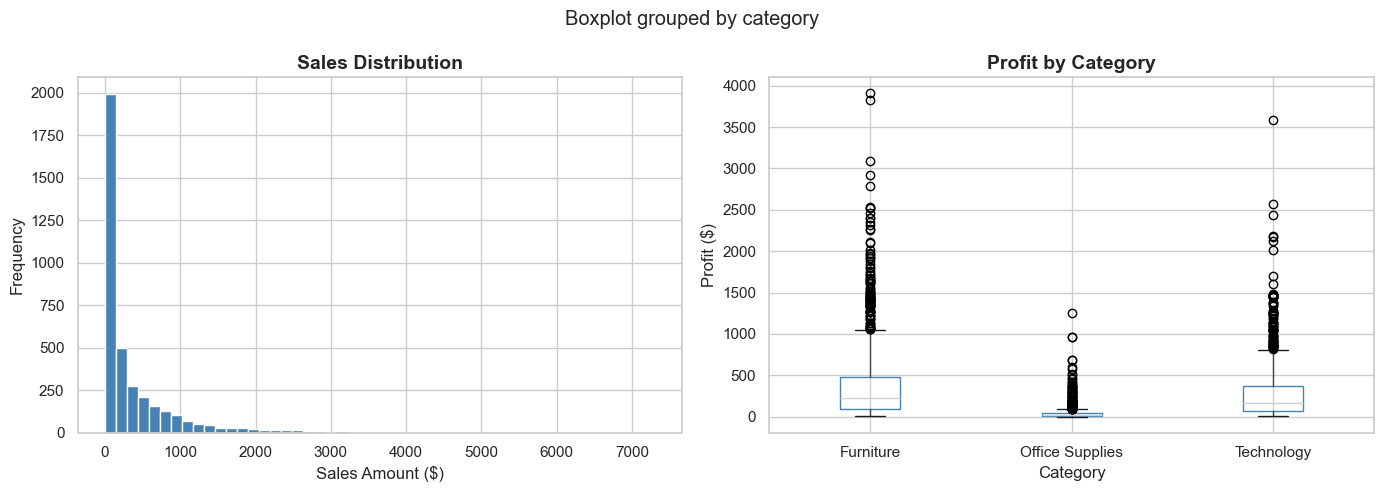

In [16]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

#___ Histogrm: Sales Distribution ___
axes[0].hist(df['sales'], bins=50, color='steelblue',edgecolor='white')
axes[0].set_title('Sales Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sales Amount ($)')
axes[0].set_ylabel('Frequency')

# ___Boxplot: Profit by Category ___
df.boxplot(column='profit', by='category', ax=axes[1],
          boxprops=dict(color='steelblue'))
axes[1].set_title('Profit by Category', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Profit ($)')

plt.tight_layout()
plt.savefig('sales_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

Sales by Region and Segment

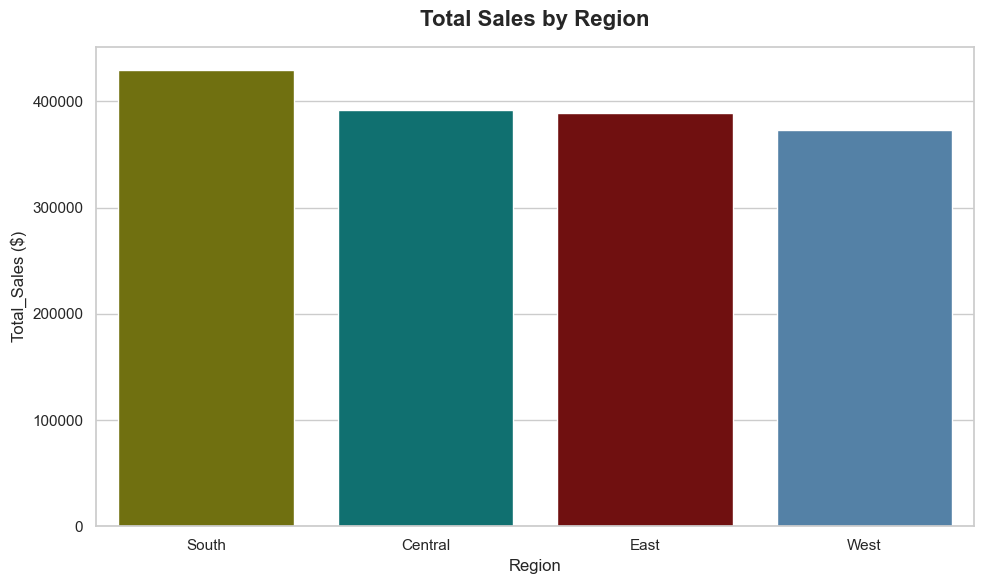

In [17]:
# ___ Bar Chart: Sales by Region ___
region_sales = df.groupby('region')['sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x = region_sales.index, y= region_sales.values,
            palette = ['olive','teal','maroon','steelblue'])
plt.title('Total Sales by Region', fontsize=16, fontweight='bold',pad=15)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Total_Sales ($)', fontsize=12)
plt.tight_layout()
plt.savefig('Total sales by Region.png')

Correlation Heatmap

In [18]:
# ___ Heatmap: Correlation Between numeric columns ____

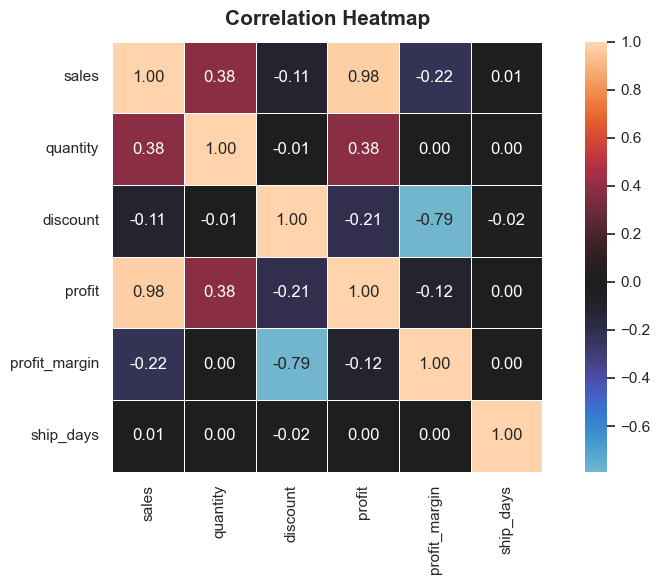

In [19]:
numeric_cols = ['sales','quantity','discount','profit','profit_margin','ship_days']
corr_matrix = df[numeric_cols].corr()
plt.figure(figsize=(9,6))
sns.heatmap(corr_matrix,
           annot=True,
           fmt='.2f',
           center=0,
           linewidths=0.5,
           square=True)
plt.title('Correlation Heatmap',fontsize=15,fontweight='bold',pad=12)
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

Exporting Data to Excel with openpyxl

In [20]:
pip install sqlalchemy psycopg2-binary openpyxl xlsxwriter

Note: you may need to restart the kernel to use updated packages.


In [21]:
import openpyxl as op

In [22]:
#__ Creating summary Dataframes ___

In [23]:
region_summary = df.groupby('region').agg(
    total_sales = ('sales','sum'),
    total_profit = ('profit','sum'),
    order_count = ('order_id','count'),
    avg_margin = ('profit_margin','mean')
).round(2).reset_index()

category_summary = df.groupby(['category','sub-category']).agg(
    total_sales = ('sales','sum'),
    total_profit = ('profit','sum'),
    avg_discount = ('discount','mean')
).round(2).reset_index()

monthly_summary = df.groupby(['order_year','order_month']).agg(
    monthly_sales = ('sales','sum'),
    monthly_profit = ('profit','sum')
).round(2).reset_index()

with pd.ExcelWriter('sales_summary.xlsx', engine='openpyxl') as writer:
    df.to_excel(writer, sheet_name='Raw Data', index=False)
    region_summary.to_excel(writer, sheet_name='Region Summary', index=False)
    category_summary.to_excel(writer, sheet_name='Category Summary', index=False)
    monthly_summary.to_excel(writer, sheet_name='Monthly Trend', index=False)

print('Excel File Created: sales_summary.xlsx')


Excel File Created: sales_summary.xlsx


In [34]:
from openpyxl import load_workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

wb = load_workbook('sales_summary.xlsx')

#____ Helper: format a worksheet ____

def format_sheet(ws):
    header_fill = PatternFill('solid',fgColor='1F4E79')
    header_font = Font(bold=True, color='FFFFFF',size=11)
    thin = Side(style='thin',color='CCCCCC')
    border = Border(left=thin, right=thin, top=thin, bottom=thin)
    
     #Format header row
    for cell in ws[1]:
        cell.fill = header_fill
        cell.font = header_font
        cell.alignment = Alignment(horizontal='center', vertical='center')
        cell.border = border

    #Zebra stipping for data rows
    alt_fill = PatternFill('solid',fgColor='EBF3FB')
    for i, row in enumerate(ws.iter_rows(min_row=2), start=2):
        for cell in row:
            cell.border = border
            if i % 2 == 0:
                cell.fill = alt_fill
                
    # Auto-fit column widths
    for col in ws. columns:
        max_len = max(len(str(c.value or '')) for c in col)
        ws.column_dimensions[get_column_letter(col[0].column)].width = min(max_len + 4, 30)
 # ___ Apply formatting to all sheets ___

for sheet_name in wb.sheetnames:
    format_sheet(wb[sheet_name])

wb.save('sales_summary.xlsx')
print('Excel formatting Applied')

Excel formatting Applied


Importing data to postgresql

In [41]:
!pip install psycopg2-binary sqlalchemy
from sqlalchemy import create_engine


In [43]:
DB_USER     = 'postgres'       # default PostgreSQL username
DB_PASSWORD = '123'       # YOUR password set during install
DB_HOST     = 'localhost'      # running on your own machine
DB_PORT     = '5432'           # default PostgreSQL port
DB_NAME     = 'globalmart_db'  # database you created in pgAdmin
engine = create_engine(f'postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}')

table_name = "analysis_table"
df.to_sql(table_name, engine, if_exists="replace", index=False)



795